# Synthetic TCSPC Dataset Generation and Analysis

This notebook demonstrates how to generate a collection of synthetic time-correlated single-photon counting (TCSPC) decay curves.

Each curve is represented in two complementary forms:

1. **Matrix representation**

   Suitable for machine-learning workflows:

   ```text
   X.shape == (n_curves, n_time_bins)
   y.shape == (n_curves,)

2. **Long-table representation**

    Suitable for CSV export, inspection, grouping, and plotting.

Each curve is associated with metadata describing its true lifetime, amplitude, background level, and photon-count statistics.

Version 0.1 uses Poisson-sampled mono-exponential decays without instrument-response-function convolution.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tcspc_toolkit.datasets import generate_monoexponential_dataset

## Define the common time axis

All generated curves use the same time bins.

The time axis runs from 0 to 20 ns and contains 256 bins.

In [2]:
time = np.linspace(
    0.0,
    20.0,
    256,
    dtype=np.float64,
)

print(f"Number of time bins: {time.size}")
print(f"First time value: {time[0]:.3f} ns")
print(f"Last time value: {time[-1]:.3f} ns")

Number of time bins: 256
First time value: 0.000 ns
Last time value: 20.000 ns


## Generate the synthetic dataset

The generator samples:

- lifetimes between 0.5 and 5.0 ns;
- provisional amplitudes between 100 and 2,000 counts;
- provisional backgrounds between 0 and 20 counts per bin;
- target expected photon counts between 1,000 and 100,000 photons.

The amplitude and background are scaled together so that each expected curve has its sampled target photon count.

A fixed random seed makes the generated dataset reproducible.

In [3]:
dataset = generate_monoexponential_dataset(
    n_curves=1_000,
    time=time,
    lifetime_range=(0.5, 5.0),
    amplitude_range=(100.0, 2_000.0),
    background_range=(0.0, 20.0),
    photon_count_range=(1_000, 100_000),
    random_seed=42,
)

In [4]:
print(f"X shape: {dataset.X.shape}")
print(f"Metadata shape: {dataset.metadata.shape}")
print(f"Time shape: {dataset.time.shape}")

dataset.metadata.columns.tolist()

X shape: (1000, 256)
Metadata shape: (1000, 7)
Time shape: (256,)


['curve_id',
 'lifetime_true',
 'amplitude_true',
 'background_true',
 'photon_count_target',
 'photon_count_expected',
 'photon_count']

In [5]:
target_name = "lifetime_true"

y = dataset.get_targets(target_name).ravel()

print(f"Selected target: {target_name}")
print(f"y shape: {y.shape}")

Selected target: lifetime_true
y shape: (1000,)


## Matrix representation

`dataset.X` contains the measured photon-count curves.

Each row represents one TCSPC curve, and each column represents one time bin.

`y` contains the corresponding true lifetimes.

In [6]:
print("First five lifetime targets:")
print(y[:5])

print("\nFirst ten time-bin counts from curve 0:")
print(dataset.X[0, :10])

First five lifetime targets:
[3.98280222 2.47495298 4.36369064 3.63815613 0.92379807]

First ten time-bin counts from curve 0:
[941 951 914 914 933 875 854 837 779 806]


In [7]:
n_curves, n_time_bins = dataset.X.shape

assert n_curves == len(y)
assert n_curves == len(dataset.metadata)
assert n_time_bins == len(dataset.time)

print("Matrix, target, metadata, and time dimensions are consistent.")

Matrix, target, metadata, and time dimensions are consistent.


## Curve-level metadata

The metadata table contains one row per generated curve.

The columns distinguish between:

- `photon_count_target`: sampled target expected photon count;
- `photon_count_expected`: sum of the final expected decay curve;
- `photon_count`: realized photon count after Poisson sampling.

Because of Poisson noise, the measured photon count generally differs from the target count.

In [8]:
dataset.metadata.head()

,curve_id,lifetime_true,amplitude_true,background_true,photon_count_target,photon_count_expected,photon_count
0,0,3.982802,880.556850,68.105152,62300,62300.0,62666
1,1,2.474953,2415.270290,22.213941,83093,83093.0,83235
2,2,4.363691,923.509752,50.996015,64379,64379.0,63867
3,3,3.638156,1082.510932,36.181547,59816,59816.0,60007
4,4,0.923798,3709.769132,6.607941,47268,47268.0,47308


In [9]:
dataset.metadata.describe()

,curve_id,lifetime_true,amplitude_true,background_true,photon_count_target,photon_count_expected,photon_count
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,2.737300,1607.281973,20.338810,47968.335000,47968.335000,47960.451000
std,288.819436,1.312136,1560.042353,28.719124,28675.793186,28675.793186,28673.696431
min,0.000000,0.505549,22.978105,0.009224,1081.000000,1081.000000,1091.000000
25%,249.750000,1.581167,589.791325,3.357748,23214.250000,23214.250000,23213.250000
50%,499.500000,2.726708,1228.734129,10.616130,47550.000000,47550.000000,47470.000000
75%,749.250000,3.915020,1974.931240,24.088409,72348.500000,72348.500000,72312.000000
max,999.000000,4.995971,11665.916022,281.903666,99942.000000,99942.000000,100196.000000


In [10]:
np.testing.assert_array_equal(
    y,
    dataset.metadata["lifetime_true"].to_numpy(),
)

print("The target vector agrees with the lifetime metadata.")

The target vector agrees with the lifetime metadata.


In [11]:
photon_count_difference = (
    dataset.metadata["photon_count_expected"]
    - dataset.metadata["photon_count_target"]
)

print(
    "Maximum absolute difference between expected and target "
    f"photon counts: {photon_count_difference.abs().max():.3e}"
)

Maximum absolute difference between expected and target photon counts: 4.366e-11


In [12]:
measured_totals_from_X = dataset.X.sum(axis=1)

np.testing.assert_array_equal(
    measured_totals_from_X,
    dataset.metadata["photon_count"].to_numpy(),
)

print("Measured photon-count metadata agrees with the rows of X.")

Measured photon-count metadata agrees with the rows of X.


## Convert to long-table format

The matrix representation is convenient for machine learning, but it does not directly associate every measured time bin with the physical parameters of its curve.

The long-table representation contains one row for every combination of curve and time bin.

In [13]:
long_dataframe = dataset.to_long_dataframe()

print(f"Long-table shape: {long_dataframe.shape}")
long_dataframe.head()
long_dataframe.columns.tolist()

Long-table shape: (256000, 9)


['curve_id',
 'time_bin',
 'counts',
 'lifetime_true',
 'amplitude_true',
 'background_true',
 'photon_count_target',
 'photon_count_expected',
 'photon_count']

In [14]:
expected_number_of_rows = (
    dataset.X.shape[0] * dataset.X.shape[1]
)

assert len(long_dataframe) == expected_number_of_rows

print(
    f"The long table contains {len(long_dataframe):,} rows, "
    "as expected."
)

The long table contains 256,000 rows, as expected.


In [15]:
curve_id = 0

curve_dataframe = long_dataframe.loc[
    long_dataframe["curve_id"] == curve_id
]

curve_dataframe.head()

,curve_id,time_bin,counts,lifetime_true,amplitude_true,background_true,photon_count_target,photon_count_expected,photon_count
0,0,0.000000,941,3.982802,880.55685,68.105152,62300,62300.0,62666
1,0,0.078431,951,3.982802,880.55685,68.105152,62300,62300.0,62666
2,0,0.156863,914,3.982802,880.55685,68.105152,62300,62300.0,62666
3,0,0.235294,914,3.982802,880.55685,68.105152,62300,62300.0,62666
4,0,0.313725,933,3.982802,880.55685,68.105152,62300,62300.0,62666


In [16]:
np.testing.assert_array_equal(
    curve_dataframe["counts"].to_numpy(),
    dataset.X[curve_id],
)

np.testing.assert_allclose(
    curve_dataframe["time_bin"].to_numpy(),
    dataset.time,
)

print(
    "The long-table values agree with the matrix representation "
    f"for curve {curve_id}."
)

The long-table values agree with the matrix representation for curve 0.


## Plot selected synthetic decay curves

A few curves are selected from different parts of the dataset.

Their shapes differ because lifetime, background level, and total photon count vary between curves.

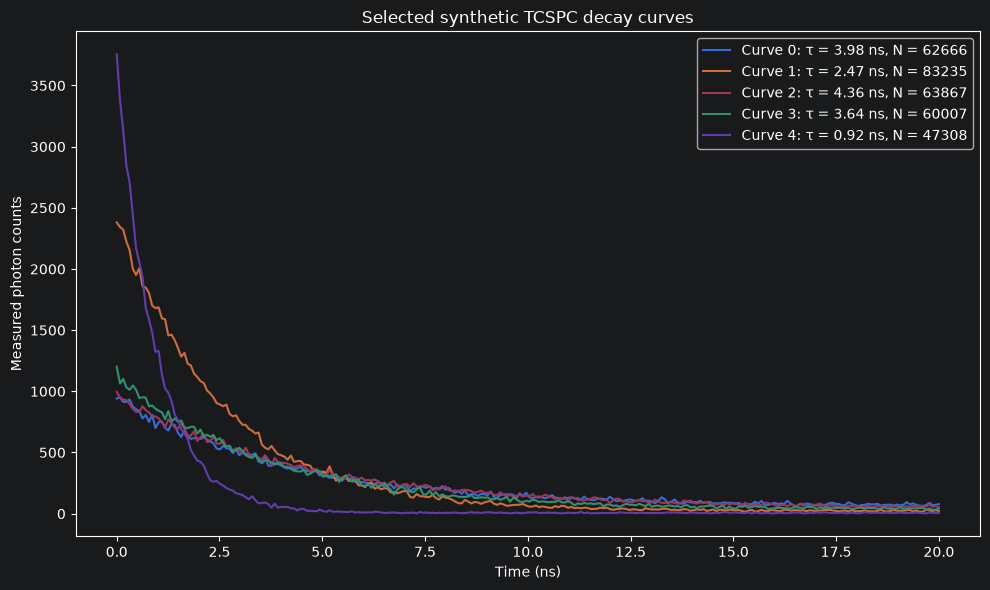

In [17]:
selected_curve_ids = [0, 1, 2, 3, 4]

plt.figure(figsize=(10, 6))

for selected_curve_id in selected_curve_ids:
    curve = long_dataframe.loc[
        long_dataframe["curve_id"] == selected_curve_id
    ]

    lifetime = curve["lifetime_true"].iloc[0]
    photon_count = curve["photon_count"].iloc[0]

    plt.plot(
        curve["time_bin"],
        curve["counts"],
        label=(
            f"Curve {selected_curve_id}: "
            f"τ = {lifetime:.2f} ns, "
            f"N = {photon_count}"
        ),
    )

plt.xlabel("Time (ns)")
plt.ylabel("Measured photon counts")
plt.title("Selected synthetic TCSPC decay curves")
plt.legend()
plt.tight_layout()
plt.show()

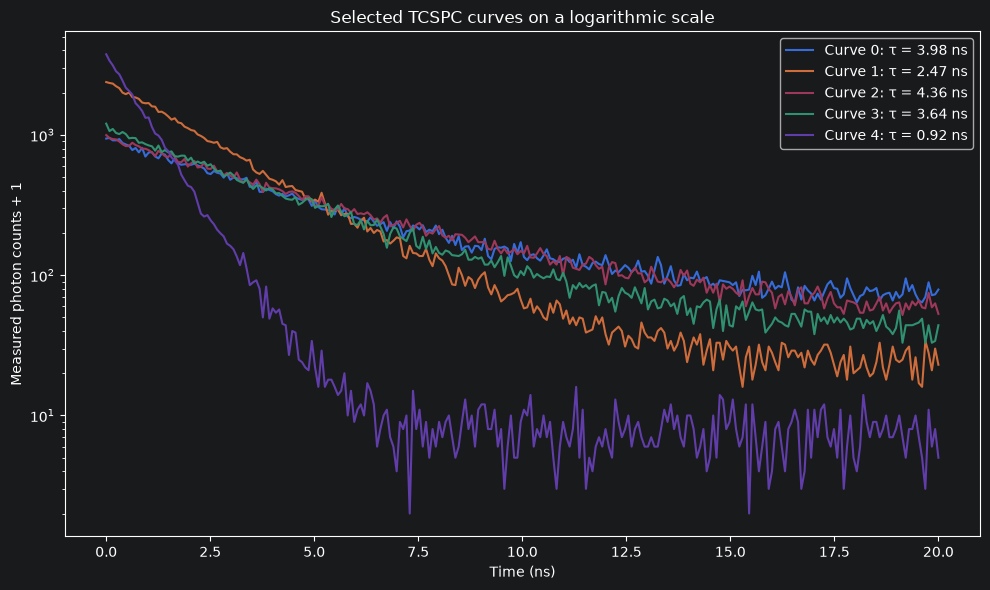

In [18]:
plt.figure(figsize=(10, 6))

for selected_curve_id in selected_curve_ids:
    curve = long_dataframe.loc[
        long_dataframe["curve_id"] == selected_curve_id
    ]

    lifetime = curve["lifetime_true"].iloc[0]

    plt.semilogy(
        curve["time_bin"],
        curve["counts"] + 1,
        label=(
            f"Curve {selected_curve_id}: "
            f"τ = {lifetime:.2f} ns"
        ),
    )

plt.xlabel("Time (ns)")
plt.ylabel("Measured photon counts + 1")
plt.title("Selected TCSPC curves on a logarithmic scale")
plt.legend()
plt.tight_layout()
plt.show()

## Plot the lifetime distribution

The lifetimes were sampled uniformly between 0.5 and 5.0 ns.

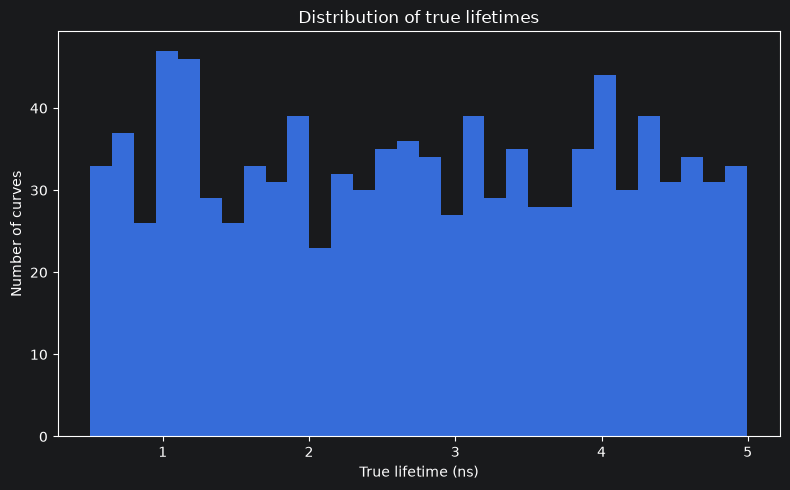

In [19]:
plt.figure(figsize=(8, 5))

plt.hist(
    dataset.metadata["lifetime_true"],
    bins=30,
)

plt.xlabel("True lifetime (ns)")
plt.ylabel("Number of curves")
plt.title("Distribution of true lifetimes")
plt.tight_layout()
plt.show()

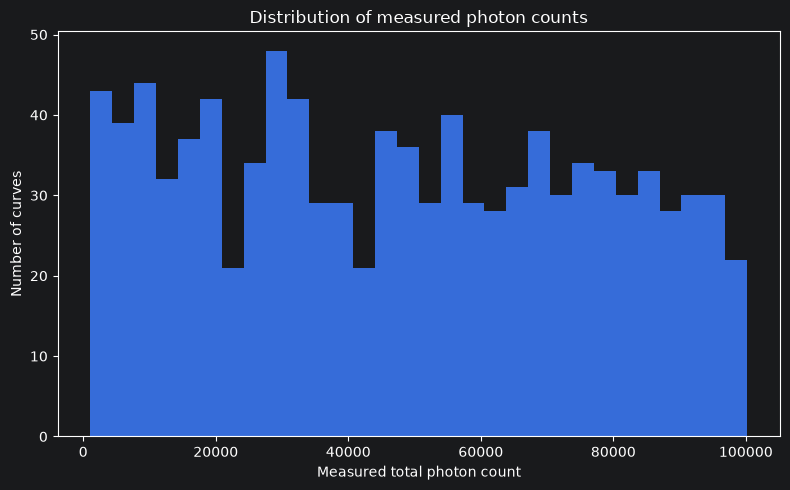

In [20]:
plt.figure(figsize=(8, 5))

plt.hist(
    dataset.metadata["photon_count"],
    bins=30,
)

plt.xlabel("Measured total photon count")
plt.ylabel("Number of curves")
plt.title("Distribution of measured photon counts")
plt.tight_layout()
plt.show()

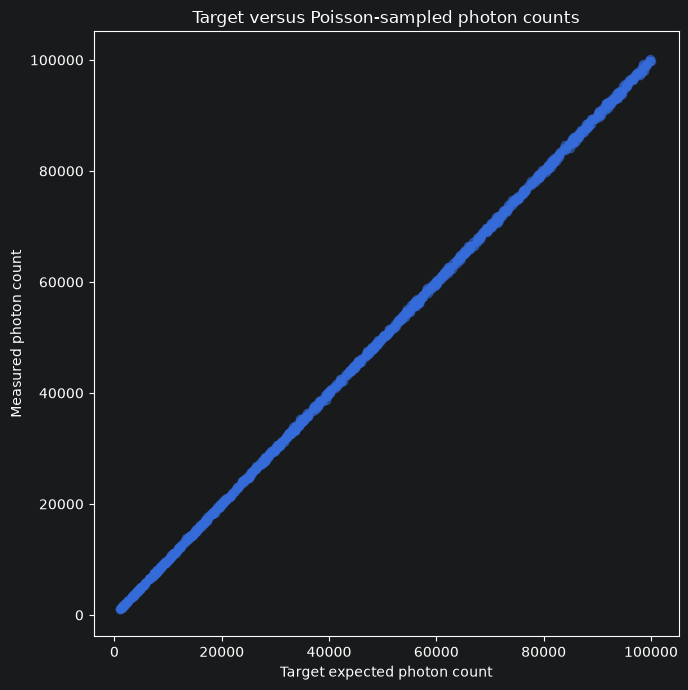

In [21]:
plt.figure(figsize=(7, 7))

plt.scatter(
    dataset.metadata["photon_count_target"],
    dataset.metadata["photon_count"],
    alpha=0.5,
)

minimum_count = dataset.metadata[
    [
        "photon_count_target",
        "photon_count",
    ]
].min().min()

maximum_count = dataset.metadata[
    [
        "photon_count_target",
        "photon_count",
    ]
].max().max()

plt.plot(
    [minimum_count, maximum_count],
    [minimum_count, maximum_count],
    linestyle="--",
)

plt.xlabel("Target expected photon count")
plt.ylabel("Measured photon count")
plt.title("Target versus Poisson-sampled photon counts")
plt.tight_layout()
plt.show()

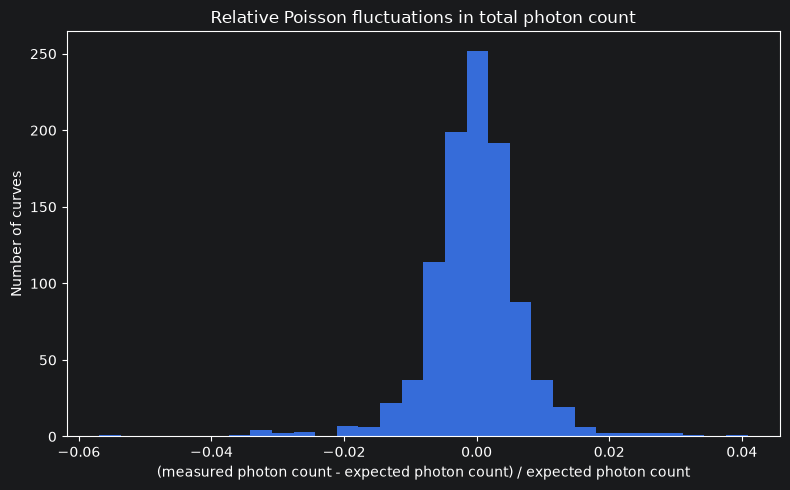

In [22]:
relative_photon_count_deviation = (
    dataset.metadata["photon_count"]
    - dataset.metadata["photon_count_expected"]
) / dataset.metadata["photon_count_expected"]

plt.figure(figsize=(8, 5))

plt.hist(
    relative_photon_count_deviation,
    bins=30,
)

plt.xlabel(
    "(measured photon count - expected photon count) "
    "/ expected photon count"
)
plt.ylabel("Number of curves")
plt.title("Relative Poisson fluctuations in total photon count")
plt.tight_layout()
plt.show()

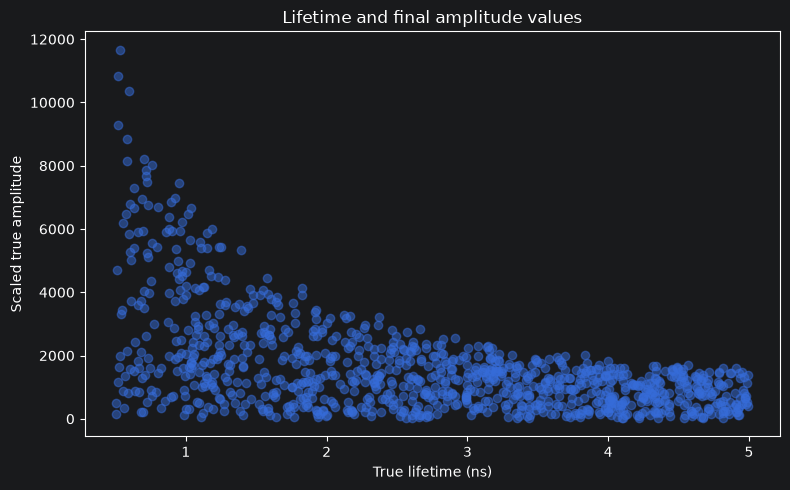

In [23]:
plt.figure(figsize=(8, 5))

plt.scatter(
    dataset.metadata["lifetime_true"],
    dataset.metadata["amplitude_true"],
    alpha=0.5,
)

plt.xlabel("True lifetime (ns)")
plt.ylabel("Scaled true amplitude")
plt.title("Lifetime and final amplitude values")
plt.tight_layout()
plt.show()

## Group curves by lifetime

For simple exploratory analysis, the curves can be divided into lifetime intervals.

This demonstrates how the metadata and long-table representations can be combined in a conventional dataframe workflow.

In [24]:
metadata_analysis = dataset.metadata.copy()

metadata_analysis["lifetime_group"] = pd.cut(
    metadata_analysis["lifetime_true"],
    bins=[0.5, 1.5, 2.5, 3.5, 5.0],
    include_lowest=True,
)

metadata_analysis.head()

,curve_id,lifetime_true,amplitude_true,background_true,photon_count_target,photon_count_expected,photon_count,lifetime_group
0,0,3.982802,880.556850,68.105152,62300,62300.0,62666,"(3.5, 5.0]"
1,1,2.474953,2415.270290,22.213941,83093,83093.0,83235,"(1.5, 2.5]"
2,2,4.363691,923.509752,50.996015,64379,64379.0,63867,"(3.5, 5.0]"
3,3,3.638156,1082.510932,36.181547,59816,59816.0,60007,"(3.5, 5.0]"
4,4,0.923798,3709.769132,6.607941,47268,47268.0,47308,"(0.499, 1.5]"


In [25]:
lifetime_group_summary = (
    metadata_analysis.groupby(
        "lifetime_group",
        observed=True,
    )
    .agg(
        number_of_curves=("curve_id", "count"),
        mean_lifetime=("lifetime_true", "mean"),
        mean_amplitude=("amplitude_true", "mean"),
        mean_background=("background_true", "mean"),
        mean_photon_count=("photon_count", "mean"),
    )
    .reset_index()
)

lifetime_group_summary

,lifetime_group,number_of_curves,mean_lifetime,mean_amplitude,mean_background,mean_photon_count
0,"(0.499, 1.5]",233,0.994701,3126.351240,35.955133,47933.463519
1,"(1.5, 2.5]",212,1.994439,1597.878512,20.273454,46033.042453
2,"(2.5, 3.5]",222,2.998518,1174.770153,15.594646,49213.752252
3,"(3.5, 5.0]",333,4.255384,838.717464,12.616457,48370.858859


In [26]:
long_dataframe_with_groups = long_dataframe.merge(
    metadata_analysis[
        [
            "curve_id",
            "lifetime_group",
        ]
    ],
    on="curve_id",
    how="left",
    validate="many_to_one",
)

mean_curves = (
    long_dataframe_with_groups.groupby(
        [
            "lifetime_group",
            "time_bin",
        ],
        observed=True,
    )["counts"]
    .mean()
    .reset_index(name="mean_counts")
)

mean_curves.head()

,lifetime_group,time_bin,mean_counts
0,"(0.499, 1.5]",0.000000,3157.394850
1,"(0.499, 1.5]",0.078431,2892.763948
2,"(0.499, 1.5]",0.156863,2636.832618
3,"(0.499, 1.5]",0.235294,2419.875536
4,"(0.499, 1.5]",0.313725,2211.008584


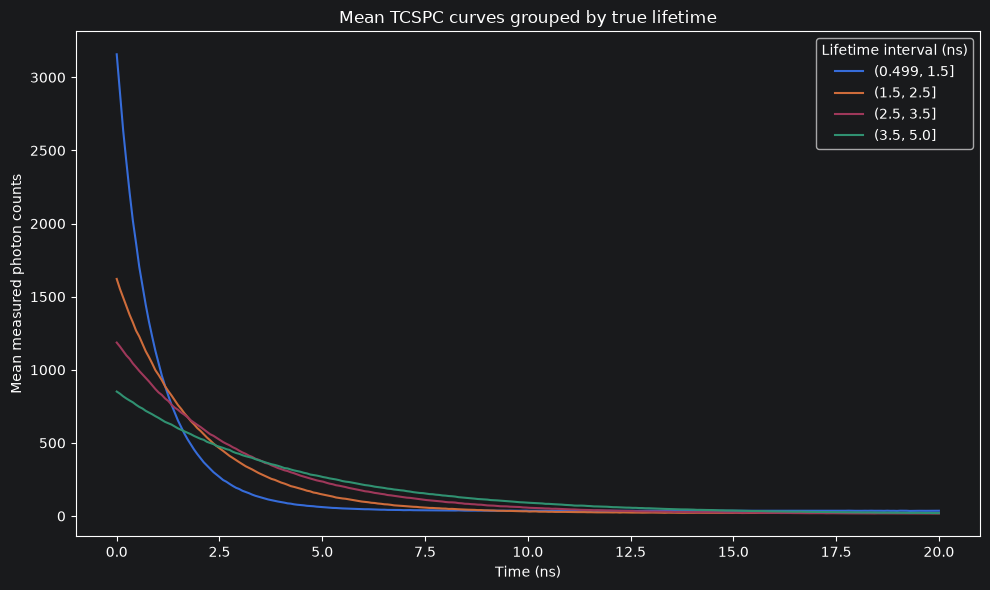

In [27]:
plt.figure(figsize=(10, 6))

for lifetime_group, group_dataframe in mean_curves.groupby(
    "lifetime_group",
    observed=True,
):
    plt.plot(
        group_dataframe["time_bin"],
        group_dataframe["mean_counts"],
        label=str(lifetime_group),
    )

plt.xlabel("Time (ns)")
plt.ylabel("Mean measured photon counts")
plt.title("Mean TCSPC curves grouped by true lifetime")
plt.legend(title="Lifetime interval (ns)")
plt.tight_layout()
plt.show()

In [28]:
long_dataframe_with_groups["normalized_counts"] = (
    long_dataframe_with_groups["counts"]
    / long_dataframe_with_groups["photon_count"]
)

mean_normalized_curves = (
    long_dataframe_with_groups.groupby(
        [
            "lifetime_group",
            "time_bin",
        ],
        observed=True,
    )["normalized_counts"]
    .mean()
    .reset_index()
)

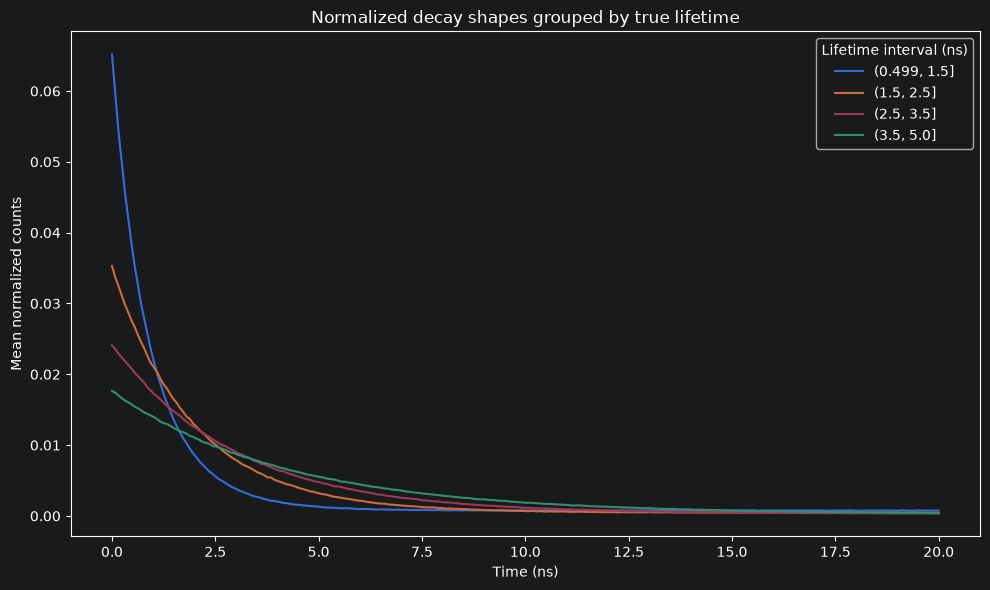

In [29]:
plt.figure(figsize=(10, 6))

for lifetime_group, group_dataframe in (
    mean_normalized_curves.groupby(
        "lifetime_group",
        observed=True,
    )
):
    plt.plot(
        group_dataframe["time_bin"],
        group_dataframe["normalized_counts"],
        label=str(lifetime_group),
    )

plt.xlabel("Time (ns)")
plt.ylabel("Mean normalized counts")
plt.title("Normalized decay shapes grouped by true lifetime")
plt.legend(title="Lifetime interval (ns)")
plt.tight_layout()
plt.show()

## Save the long-table dataset

The full long-table dataframe can be saved as a CSV file.

For 1,000 curves with 256 bins, the resulting table contains 256,000 rows. This representation is readable and convenient for analysis, but it is less storage-efficient than the matrix representation.

In [30]:
output_directory = Path("../data/generated")
output_directory.mkdir(
    parents=True,
    exist_ok=True,
)

In [31]:
long_dataframe = dataset.to_long_dataframe()

print(f"Long DataFrame shape: {long_dataframe.shape}")
long_dataframe.head()

Long DataFrame shape: (256000, 9)


,curve_id,time_bin,counts,lifetime_true,amplitude_true,background_true,photon_count_target,photon_count_expected,photon_count
0,0,0.000000,941,3.982802,880.55685,68.105152,62300,62300.0,62666
1,0,0.078431,951,3.982802,880.55685,68.105152,62300,62300.0,62666
2,0,0.156863,914,3.982802,880.55685,68.105152,62300,62300.0,62666
3,0,0.235294,914,3.982802,880.55685,68.105152,62300,62300.0,62666
4,0,0.313725,933,3.982802,880.55685,68.105152,62300,62300.0,62666


In [32]:
csv_path = output_directory / "synthetic_tcspc_dataset.csv"

long_dataframe.to_csv(
    csv_path,
    index=False,
)

print(f"Dataset saved to: {csv_path.resolve()}")

Dataset saved to: C:\Users\Yevhenii\PycharmProjects\scientific-python-transition\data\generated\synthetic_tcspc_dataset.csv


In [33]:
loaded_dataframe = pd.read_csv(csv_path)

print(f"Loaded dataframe shape: {loaded_dataframe.shape}")
loaded_dataframe.head()

Loaded dataframe shape: (256000, 9)


,curve_id,time_bin,counts,lifetime_true,amplitude_true,background_true,photon_count_target,photon_count_expected,photon_count
0,0,0.000000,941,3.982802,880.55685,68.105152,62300,62300.0,62666
1,0,0.078431,951,3.982802,880.55685,68.105152,62300,62300.0,62666
2,0,0.156863,914,3.982802,880.55685,68.105152,62300,62300.0,62666
3,0,0.235294,914,3.982802,880.55685,68.105152,62300,62300.0,62666
4,0,0.313725,933,3.982802,880.55685,68.105152,62300,62300.0,62666


In [34]:
assert loaded_dataframe.shape == long_dataframe.shape
assert loaded_dataframe.columns.tolist() == (
    long_dataframe.columns.tolist()
)

print("The exported CSV has the expected shape and columns.")

The exported CSV has the expected shape and columns.


## Save the machine-learning representation

CSV is not the most efficient format for a dense machine-learning matrix.

NumPy's compressed archive format can store the feature matrix, target vector, and time axis directly.

In [35]:
matrix_path = (
    output_directory
    / "synthetic_tcspc_ml_dataset.npz"
)

np.savez_compressed(
    matrix_path,
    X=dataset.X,
    y=y,
    time=dataset.time,
)

print(f"Matrix dataset saved to: {matrix_path.resolve()}")

Matrix dataset saved to: C:\Users\Yevhenii\PycharmProjects\scientific-python-transition\data\generated\synthetic_tcspc_ml_dataset.npz


In [36]:
loaded_matrix_dataset = np.load(matrix_path)

X_loaded = loaded_matrix_dataset["X"]
y_loaded = loaded_matrix_dataset["y"]
time_loaded = loaded_matrix_dataset["time"]

print(f"Loaded X shape: {X_loaded.shape}")
print(f"Loaded y shape: {y_loaded.shape}")
print(f"Loaded time shape: {time_loaded.shape}")

Loaded X shape: (1000, 256)
Loaded y shape: (1000,)
Loaded time shape: (256,)


In [37]:
np.testing.assert_array_equal(
    X_loaded,
    dataset.X,
)

np.testing.assert_array_equal(
    y_loaded,
    y,
)

np.testing.assert_array_equal(
    time_loaded,
    dataset.time,
)

print("The saved matrix representation is fully reproducible.")

The saved matrix representation is fully reproducible.


## Conclusions

This notebook generated 1,000 synthetic TCSPC decay curves and demonstrated two dataset representations.

### Matrix representation

```text
X.shape == (1000, 256)
y.shape == (1000,)
```

This representation is appropriate for machine-learning models.

### Long-table representation

```text
long_dataframe.shape == (256000, 9)
```

This representation is convenient for:
- CSV export;
- curve-level filtering;
- analysis;
- plotting;
- metadata inspection.

The metadata preserves the physical parameters associated with every curve, including the true lifetime, final scaled amplitude, background, and photon-count statistics.

The next machine-learning stage can use `X` as the input features and `y` as the lifetime-regression target.


#### One small correction to the original example: `dataset.metadata.shape` is indeed `(1000, 7)` only when the metadata contains these seven columns:

```text
curve_id
lifetime_true
amplitude_true
background_true
photon_count_target
photon_count_expected
photon_count
```

The long dataframe then contains nine columns because it adds `time_bin` and `counts`.